<a href="https://colab.research.google.com/github/pretyjoshi/LgccPythonProject/blob/main/Capstone_project_Cesarean_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data analysis of Cesarean data from Kaggle**
## **Capstone project**: For LCC Data analysis Course
Submitted by: **Preeti Joshi Kandpal**
Date: 01/25/2026


To used the notebook, you will need the data link for the raw data, shared via google drive.

Data Source: [cesarean Raw Dataset at Kaggle](https://www.kaggle.com/datasets/hassnainakbar/caesarian-raw-dataset)

This raw dataset includes uncleaned, de-identified data, from 4 million women.
It focuses on factors influencing Caesarean (C‑section) deliveries.
It covers data related to demographics, lifestyle choices, medical conditions, and historical pregnancy details from pregnenet women.

*   **Demographics**:
    1.   Age
    2.   Residence
    3.   Income Bracket
    4.   Mother's Education Level
*   **Medical & Clinical**:
    5.   Blood Pressure status
    6.   Heart Problem
    7.   Iron Level
    8.   Blood Group
    9.   BMI (Body Mass Index)
    10.  Gestational Diabetes
*   **Lifestyle Factors**:
    11.   Smoking Status
    12.   Alcohol Use
    13.   Family History
    14.   Folic Acid Supplements
*   **Pregnancy History**:
    15.   Delivery Type
    16.   Delivery Number
    17.   Previous Miscarriage
    18.   cesarean
*   **Administrative**:
    19.   IDs
    20.   Hospital Code




# **Step 1**: Data Import

First step is to import all the libraries in python, and check versions.

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency

# Plot settings (optional)
plt.style.use('default')
sns.set(style='whitegrid')

# Show versions (useful when sharing notebooks)
import sys
print('Python version:', sys.version)
print('Pandas version:', pd.__version__)
print('Seaborn version:', sns.__version__)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas version: 2.2.2
Seaborn version: 0.13.2


  Next step in data import includes importing the raw data from the google drive using the shared link.

  The data is too big to share via Github repository link, which allows only 100mb of data.
  Thus one cannot  upload it using raw data link from personal Git repositories.
  To share larger data on git,  Git Large File Storage (LFS) is required.
    
  But I found google drive as an easier alternative option.
  To share big data from google dive, a python library, **gdown** is needed.

  Using gdown, I was able to upload big data directly from google drive to Colab.

In [2]:
## pip install gdown
import gdown

## public share link with data in google drive
## https://drive.google.com/file/d/1OyNtVyADlDQ8hUBhW-2UDABXgAHZyTau/view?usp=sharing)

file_id = "1OyNtVyADlDQ8hUBhW-2UDABXgAHZyTau"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "Cesarean_data.csv", quiet=False)

data_raw = pd.read_csv("Cesarean_data.csv", low_memory=False)


Downloading...
From (original): https://drive.google.com/uc?id=1OyNtVyADlDQ8hUBhW-2UDABXgAHZyTau
From (redirected): https://drive.google.com/uc?id=1OyNtVyADlDQ8hUBhW-2UDABXgAHZyTau&confirm=t&uuid=08d15263-0ee9-4686-8bbd-a06e46323da4
To: /content/Cesarean_data.csv
100%|██████████| 479M/479M [00:08<00:00, 57.1MB/s]


# **Step 2**. Quick Data Overview

In this section we:
- Look at the first and last few rows
- Check shape (rows, columns)
- Get column names and data types
- Get high-level info and basic statistics

In [3]:
df=data_raw
display(df.head())
display(df.tail())
print('\n Shape (rows, columns):', df.shape, '\n')
df.info()



,Unnamed: 0,Age,Delivery No,Delivery Type,Blood Pressure,Heart Problem,Caesarian,BMI,Smoking Status,Alcohol Use,Family History,Gestational Diabetes,Hospital_Code,Mother's Education Level,Residence,Income Bracket,Folic Acid Supplements,Previous Miscarriage,Iron Level,Blood Group
0,1,18.0,2,Premature,High,Yes,Yes,18.7,yes,no,no,NaN,NaN,HighSchool,NaN,NaN,NaN,1,6.1,B+
1,2,20.0,3,Timely,Low,yes,False,20.7,NO,yes,NaN,no,NaN,Graduate,Ubanr,High,yes,no,10.6,O-
2,3,39.0,0,Premature,Normal,n,1,32.1,NaN,no,Yes,yes,HSP002,HighSchool,Rurl,Medium,NaN,1,12.0,O-
3,4,31.0,4,Emergency,Normal,yes,Yes,21.4,no,NO,NaN,yes,HSP004,Illiterate,Rurl,Low,NaN,yes,12.4,AB+
4,5,-1.0,2,Premature,High,y,False,22.4,YES,no,NaN,NaN,HSP001,Graduate,Urban,High,yes,yes,12.8,A-


,Unnamed: 0,Age,Delivery No,Delivery Type,Blood Pressure,Heart Problem,Caesarian,BMI,Smoking Status,Alcohol Use,Family History,Gestational Diabetes,Hospital_Code,Mother's Education Level,Residence,Income Bracket,Folic Acid Supplements,Previous Miscarriage,Iron Level,Blood Group
3999995,3999996,43.0,1,Emergency,120/80,no,False,27.9,no,YES,NaN,no,HSP002,College,banU,High,no,NaN,13.4,A-
3999996,3999997,26.0,3,Timely,High,n,1,-5.0,no,NaN,Yes,yes,hsp003,Graduate,Rural,Medium,yes,1,14.2,B-
3999997,3999998,37.0,1,Dlayede,120/80,no,False,-5.0,NO,NO,NaN,no,HSP004,Graduate,Rural,High,NaN,NaN,8.5,AB+
3999998,3999999,30.0,0,Timely,Normal,yes,False,28.2,NaN,no,No,yes,hsp003,Illiterate,Uban,Medium,no,NaN,17.3,B+
3999999,4000000,25.0,2,Timely,110/70,no,Yes,31.8,NO,yes,yes,no,HSP004,Illiterate,Rural,NaN,NaN,NaN,14.2,AB+



 Shape (rows, columns): (4000000, 20) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 20 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Unnamed: 0                int64  
 1   Age                       float64
 2   Delivery No               int64  
 3   Delivery Type             object 
 4   Blood Pressure            object 
 5   Heart Problem             object 
 6   Caesarian                 object 
 7   BMI                       float64
 8   Smoking Status            object 
 9   Alcohol Use               object 
 10  Family History            object 
 11  Gestational Diabetes      object 
 12  Hospital_Code             object 
 13  Mother's Education Level  object 
 14  Residence                 object 
 15  Income Bracket            object 
 16  Folic Acid Supplements    object 
 17  Previous Miscarriage      object 
 18  Iron Level                float64
 19  Blood Group           

Total 4 million rows for 20 variable (4000000 entries, 20 columns)

There could be duplicated values, missing data, textual inconsistencies, and outliers.





# **Step 3**: Data Quality check

Column number of patient id is "Unnamed"

Categorical and Numerical columns need to be fixed separately.

Many categories lack standardized format, e.g. Heart Problem has values 'Yes', 'yes', 'n', 'y', etc.

Some lacks typological inconsistencies, e.g. resident types are 'Ubanr', 'Rulr', 'Urban', 'Rular', etc.

There are numeric like varaible in categorical data e.g. Blood Pressure 120/80 and other numerical entries. Similarly, numeric data can have non-numeric entries.

In [4]:
# 1.  Renaming unidentified column
df.rename(columns={df.columns[0]: "IDs"}, inplace=True)
df["IDs"] = "ID_" + df["IDs"].astype(str)
df.rename(columns={df.columns[6]: "Cesarean"}, inplace=True)



# 2. Defining Categorical columns and  capatalizing all categories, to remove inconsistent capitalization
categor_cols = df.select_dtypes(include="object").columns

for col in categor_cols:
    # Capitalize first letter
    df[col] = df[col].str.capitalize()

# 3. Identifying numeric columns and converting its all its non-numeric values to NA
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'number']).columns
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 20 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   IDs                       object 
 1   Age                       float64
 2   Delivery No               int64  
 3   Delivery Type             object 
 4   Blood Pressure            object 
 5   Heart Problem             object 
 6   Cesarean                  object 
 7   BMI                       float64
 8   Smoking Status            object 
 9   Alcohol Use               object 
 10  Family History            object 
 11  Gestational Diabetes      object 
 12  Hospital_Code             object 
 13  Mother's Education Level  object 
 14  Residence                 object 
 15  Income Bracket            object 
 16  Folic Acid Supplements    object 
 17  Previous Miscarriage      object 
 18  Iron Level                float64
 19  Blood Group               object 
dtypes: float64(3), int64(1),

,IDs,Age,Delivery No,Delivery Type,Blood Pressure,Heart Problem,Cesarean,BMI,Smoking Status,Alcohol Use,Family History,Gestational Diabetes,Hospital_Code,Mother's Education Level,Residence,Income Bracket,Folic Acid Supplements,Previous Miscarriage,Iron Level,Blood Group
0,Id_1,18.0,2,Premature,High,Yes,Yes,18.7,Yes,No,No,NaN,NaN,Highschool,NaN,NaN,NaN,1,6.1,B+
1,Id_2,20.0,3,Timely,Low,Yes,False,20.7,No,Yes,NaN,No,NaN,Graduate,Ubanr,High,Yes,No,10.6,O-
2,Id_3,39.0,0,Premature,Normal,N,1,32.1,NaN,No,Yes,Yes,Hsp002,Highschool,Rurl,Medium,NaN,1,12.0,O-
3,Id_4,31.0,4,Emergency,Normal,Yes,Yes,21.4,No,No,NaN,Yes,Hsp004,Illiterate,Rurl,Low,NaN,Yes,12.4,Ab+
4,Id_5,-1.0,2,Premature,High,Y,False,22.4,Yes,No,NaN,NaN,Hsp001,Graduate,Urban,High,Yes,Yes,12.8,A-


# Checking for missing data and duplicated rows

Head and tail view suggests there   are several rows with missing (NaN or NA) values.

In [5]:
# 4. Perform missing data exploration
# Finding out columns with most missing data
print('\nMissing values per column (percentage):')
missing_pct = df.isnull().mean() * 100
display(missing_pct.sort_values(ascending=False))

## Plot of  missing values # Skipped due to large data size.
#plt.figure(figsize=(10, 6))
#sns.heatmap(df.isnull(), cbar=False)
#plt.title('Missing Values Heatmap')
#plt.show()

# 5. Identify duplicated rows
num_duplicates = df.duplicated().sum()
print('Number of duplicate rows:', num_duplicates)



Missing values per column (percentage):


,0
Folic Acid Supplements,33.356500
Gestational Diabetes,33.329500
Income Bracket,24.992850
Hospital_Code,20.045875
Smoking Status,20.023575
Previous Miscarriage,20.006575
Alcohol Use,19.995525
Family History,19.975875
Residence,19.668400
Iron Level,9.979150


Number of duplicate rows: 0


1. Nine categorical and four numeric columns have missing data.
2. There are many inconsistencies related to spellings.
3. No duplicated rows found

*   Numerical data can be imputed.
*   For categorical data, a new category, "Unknown", can be added.






In [6]:
# 6. Identify mismatch in  spellings of categories
# Checking categories for uniformity in term of data type and/or spellings.

unique_values = {col: df[col].unique() for col in categor_cols}
unique_values

{'IDs': array(['Id_1', 'Id_2', 'Id_3', ..., 'Id_3999998', 'Id_3999999',
        'Id_4000000'], dtype=object),
 'Delivery Type': array(['Premature', 'Timely', 'Emergency', 'Delayed', 'Tmelyi',
        'Emerencyg', 'Imelyt', 'Prematuer', 'Delayde', 'Preaturem',
        'Timlye', 'Emrgencye', 'Eergencym', 'Delyeda', 'Tielym',
        'Pematurer', 'Prematreu', 'Emergncye', 'Emergenyc', 'Mergencye',
        'Emergecyn', 'Elayedd', 'Prmaturee', 'Timeyl', 'Delaedy',
        'Premturea', 'Deayedl', 'Premauret', 'Rematurep', 'Dlayede',
        'Emegencyr'], dtype=object),
 'Blood Pressure': array(['High', 'Low', 'Normal', '110/70', '120/80', nan, '10/802',
        '12080/', 'Ighh', 'Nomalr', '10/701', '120/08', '11/700', 'Hihg',
        'Nrmalo', 'Noralm', 'Lowx', 'Hghi', '20/801', '11070/', 'Ormaln',
        '12/800', '110/07', 'Normla'], dtype=object),
 'Heart Problem': array(['Yes', 'N', 'Y', 'No'], dtype=object),
 'Cesarean': array(['Yes', 'False', '1', 'True', 'No', '0'], dtype=object),
 '

#**Step 4**: Data Standardization and cleaning
In this step, I cleaned the data and standardized the categories.

  1. Correct categories
     - For Delivery Type, Blood Pressure, etc.
  2. Impute missing values for categorical data
  3. Impute missing value for numerical data



In [7]:
# 1. Standardization of Delivery Type
# Delivery type has several spelling inconsistencies
#['Premature', 'Timely', 'Emergency', 'Delayed', 'Tmelyi','Emerencyg', 'Imelyt', 'Prematuer', 'Delayde', 'Preaturem',
#'Timlye', 'Emrgencye', 'Eergencym', 'Delyeda', 'Tielym','Pematurer', 'Prematreu', 'Emergncye', 'Emergenyc', 'Mergencye',
#'Emergecyn', 'Elayedd', 'Prmaturee', 'Timeyl', 'Delaedy','Premturea', 'Deayedl', 'Premauret', 'Rematurep', 'Dlayede','Emegencyr']

D_types1 = {"Premature","Prematuer","Preaturem", "Pematurer","Prematreu","Pematurer","Prematreu","Prmaturee","Premturea","Premauret","Rematurep"}
D_types2 = {"Timely","Imelyt","Timlye", "Tielym","Tielym","Timeyl"}
D_types3 = {"Emergency","Emerencyg","Emrgencye", "Eergencym", "Emergncye","Emergenyc","Mergencye","Emergecyn","Emegencyr" }
D_types4 ={"Delayed","Delayde","Delyeda", "Elayedd","Delaedy","Deayedl","Dlayede"}

def D_time(x):
    if pd.isna(x):
        return "Unknown"
    if x in D_types1:
        return "Premature"
    if x in D_types2:
        return "Timely"
    if x in D_types3:
        return "Emergency"
    if x in D_types4:
        return "Delayed"
    return "Unknown"

df["Delivery Type"] = df["Delivery Type"].apply(D_time).astype("category")
df["Delivery Type"].unique()


['Premature', 'Timely', 'Emergency', 'Delayed', 'Unknown']
Categories (5, object): ['Delayed', 'Emergency', 'Premature', 'Timely', 'Unknown']

In [8]:
# 2. Standardization of Blood Pressure entries
#['High', 'Low', 'Normal', '110/70', '120/80', nan, '10/802','12080/', 'Ighh', 'Nomalr', '10/701', '120/08', '11/700', 'Hihg',
# 'Nrmalo', 'Noralm', 'Lowx', 'Hghi', '20/801', '11070/', 'Ormaln','12/800', '110/07', 'Normla']
Bp_val1={"High","Ighh","Hihg","Hghi"}
Bp_val2={"Low","110/70","10/701","11/700","11070/","10/07", "Lowx"}
Bp_val3={"Normal","120/80","10/802","12080/","Nomalr","120/08","Nrmalo","Noralm","20/801","Ormaln","12/800","Normla"}
def BP_type(x):
    if pd.isna(x):
        return "Unknown"
    if x in Bp_val1:
        return "High"
    if x in Bp_val2:
        return "Low"
    if x in Bp_val3:
        return "Normal"
    return "Unknown"
df["Blood Pressure"] = df["Blood Pressure"].apply(BP_type).astype("category")
df["Blood Pressure"].unique()


['High', 'Low', 'Normal', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown']

In [9]:
# 3. Standardization of columns with two outputs (yes/no)

YES_VALUES = {"Yes","YES", "Y", "TRUE", "True", "1"}
NO_VALUES = {"No","NO", "N","FALSE", "False", "0"}
def standardize_yes_no(x):
    if pd.isna(x):
        return "Unknown"
    if x in YES_VALUES:
        return "Yes"
    if x in NO_VALUES:
        return "No"
    return "Unknown"

yes_no_cols = ["Heart Problem","Cesarean","Smoking Status","Alcohol Use","Family History","Gestational Diabetes","Folic Acid Supplements","Previous Miscarriage"]

for col in yes_no_cols:
    df[col] = df[col].apply(standardize_yes_no).astype("object")
    df[col] = df[col].astype("category")


yes_no_unique_values = {col: df[col].unique() for col in yes_no_cols}
yes_no_unique_values


{'Heart Problem': ['Yes', 'No']
 Categories (2, object): ['No', 'Yes'],
 'Cesarean': ['Yes', 'No']
 Categories (2, object): ['No', 'Yes'],
 'Smoking Status': ['Yes', 'No', 'Unknown']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Alcohol Use': ['No', 'Yes', 'Unknown']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Family History': ['No', 'Unknown', 'Yes']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Gestational Diabetes': ['Unknown', 'No', 'Yes']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Folic Acid Supplements': ['Unknown', 'Yes', 'No']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Previous Miscarriage': ['Yes', 'No', 'Unknown']
 Categories (3, object): ['No', 'Unknown', 'Yes']}

In [10]:
# 4. Standardization of columns with "Mother's Education Level"
##  array(['Highschool', 'Graduate', 'Illiterate', 'College', 'Cllegeo','Colegel', 'Iliteratel',
## 'Colleeg', 'Highscoolh', 'Illiteraet','Illteratei', 'Highscholo', 'Ollegec', 'Gaduater', 'Gradateu','Ighschoolh', 'Illitratee',
## 'Illieratet', 'Illiteater','Illitertea', 'Highshoolc', 'Raduateg', 'Hihschoolg', 'Graduaet',
##  'Gradutea', 'Collgee', 'Hghschooli', 'Highchools', 'Grauated','Lliteratei', 'Grduatea', 'Higschoolh'], dtype=object),

MotherEd_val1={"Highschool","Highscoolh","Highshoolc","Highscholo","Ighschoolh","Hihschoolg", "Hghschooli", "Highchools","Higschoolh"}
MotherEd_val2={"Graduate","Gaduater","Gradateu","Raduateg","Graduaet","Gradutea","Grauated","Grduatea"}
MotherEd_val3={"Illiterate","Iliteratel","Illiteraet","Illteratei","Illitratee","Illieratet","Illiteater","Illitertea","Lliteratei"}
MotherEd_val4={"College","Cllegeo","Colleeg","Ollegec","Collgee"}

def MotherEd_type(x):
    if pd.isna(x):
        return "Unknown"
    if x in MotherEd_val1:
        return "Highschool"
    if x in MotherEd_val2:
        return "Graduate"
    if x in MotherEd_val3:
        return "Illiterate"
    if x in MotherEd_val4:
        return "College"
    return "Unknown"
df["Mother's Education Level"] = df["Mother's Education Level"].apply(MotherEd_type).astype("category")
df["Mother's Education Level"].unique()

['Highschool', 'Graduate', 'Illiterate', 'College', 'Unknown']
Categories (5, object): ['College', 'Graduate', 'Highschool', 'Illiterate', 'Unknown']

In [11]:
## 5. Standardization of columns with Blood Group

df["Blood Group"] = df["Blood Group"].str.replace("x", "", regex=False)
df["Blood Group"].unique()
df["Blood Group"] = df["Blood Group"].astype("category")

In [12]:
## 6. Standardization of columns with Income Bracket and Hospital code

df["Income Bracket"] = df["Income Bracket"].fillna("Unknown").astype("category")
df["Hospital_Code"] = df["Hospital_Code"].fillna("Unknown").astype("category")


In [13]:
## 7. standardization of columns with "Residence"

Residence_val1={"Ubanr","Urban","Uban","Uanb","Banu",'Ubna',"Uranb","Rbanu","Urbna"}
Residence_val2={"Rurl","Rural","Rulr","Uralr","Urlr","Rualr","Rrlu","Rurla","Rralu"}
Residence_val3={"X"}
def Residence_type(x):
    if pd.isna(x):
        return "Unknown"
    if x in Residence_val1:
        return "Urban"
    if x in Residence_val2:
        return "Rular"
    if x in Residence_val3:
        return "TitleX"
    return "Unknown"
df["Residence"] = df["Residence"].apply(Residence_type).astype("object")
df["Residence"] = df["Residence"].astype("category")
df["Residence"].unique()

['Unknown', 'Urban', 'Rular', 'TitleX']
Categories (4, object): ['Rular', 'TitleX', 'Unknown', 'Urban']

In [14]:
#  8. Correcting Missing data
display(df.info())
print('\n Missing values per column (percentage): \n ')
missing_pct = df.isnull().mean() * 100
display(missing_pct.sort_values(ascending=False))
unique_values = {col: df[col].unique() for col in categor_cols}
unique_values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 20 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   IDs                       object  
 1   Age                       float64 
 2   Delivery No               int64   
 3   Delivery Type             category
 4   Blood Pressure            category
 5   Heart Problem             category
 6   Cesarean                  category
 7   BMI                       float64 
 8   Smoking Status            category
 9   Alcohol Use               category
 10  Family History            category
 11  Gestational Diabetes      category
 12  Hospital_Code             category
 13  Mother's Education Level  category
 14  Residence                 category
 15  Income Bracket            category
 16  Folic Acid Supplements    category
 17  Previous Miscarriage      category
 18  Iron Level                float64 
 19  Blood Group               category
dtypes:

None


 Missing values per column (percentage): 
 


,0
Iron Level,9.97915
BMI,8.18145
Age,1.99230
IDs,0.00000
Delivery Type,0.00000
Delivery No,0.00000
Heart Problem,0.00000
Blood Pressure,0.00000
Smoking Status,0.00000
Alcohol Use,0.00000


{'IDs': array(['Id_1', 'Id_2', 'Id_3', ..., 'Id_3999998', 'Id_3999999',
        'Id_4000000'], dtype=object),
 'Delivery Type': ['Premature', 'Timely', 'Emergency', 'Delayed', 'Unknown']
 Categories (5, object): ['Delayed', 'Emergency', 'Premature', 'Timely', 'Unknown'],
 'Blood Pressure': ['High', 'Low', 'Normal', 'Unknown']
 Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'],
 'Heart Problem': ['Yes', 'No']
 Categories (2, object): ['No', 'Yes'],
 'Cesarean': ['Yes', 'No']
 Categories (2, object): ['No', 'Yes'],
 'Smoking Status': ['Yes', 'No', 'Unknown']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Alcohol Use': ['No', 'Yes', 'Unknown']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Family History': ['No', 'Unknown', 'Yes']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Gestational Diabetes': ['Unknown', 'No', 'Yes']
 Categories (3, object): ['No', 'Unknown', 'Yes'],
 'Hospital_Code': ['Unknown', 'Hsp002', 'Hsp004', 'Hsp001', 'Hsp003']
 Categories (5, o

# Impute missing values for numerical columns and remove visual outliers
All categorical values have been made consistent. Their missing value has been replaced with "Unknown".

Numerical columns still have missing values. But, it is less than 10 percent so we can impute them based on their distribution.

Next, I visualized numerical data distribution.

Removed any values which are outside normal range.

Impute the value based on their skewness level. i.e. if |skew| < 0.5 it means roughly symmetric so replace by mean. But skew ≥ 0.5 means skewed data so replace by median.

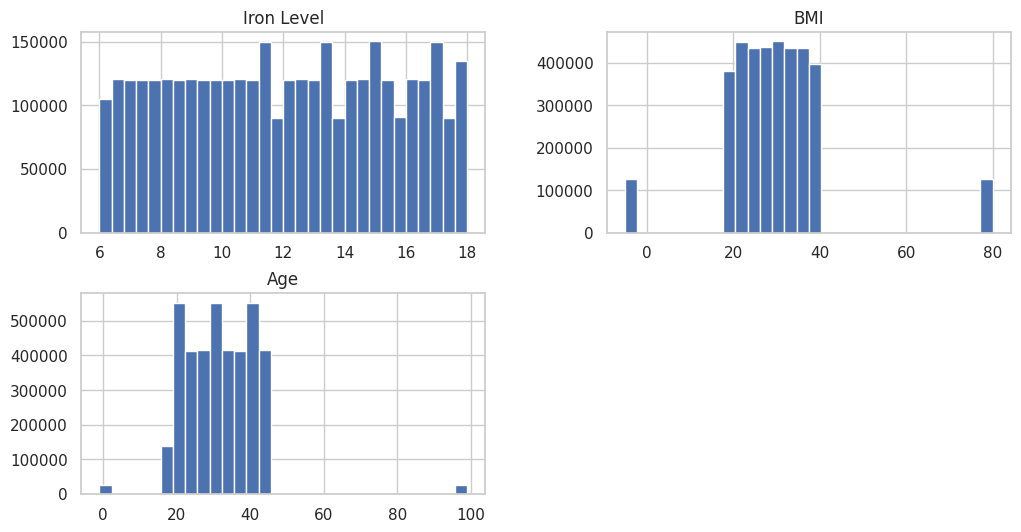

,Iron Level,BMI,Age
count,3.600834e+06,3.672742e+06,3.920308e+06
mean,1.200055e+01,2.959326e+01,3.173699e+01
std,3.463769e+00,1.292323e+01,1.009605e+01
min,6.000000e+00,-5.000000e+00,-1.000000e+00
25%,9.000000e+00,2.310000e+01,2.400000e+01
50%,1.200000e+01,2.900000e+01,3.200000e+01
75%,1.500000e+01,3.490000e+01,3.900000e+01
max,1.800000e+01,8.000000e+01,9.900000e+01


In [15]:
# Visualize the data
data_raw[["Iron Level", "BMI", "Age"]].hist(bins=30, figsize=(12,6))
plt.show()
df[["Iron Level", "BMI", "Age"]].describe()



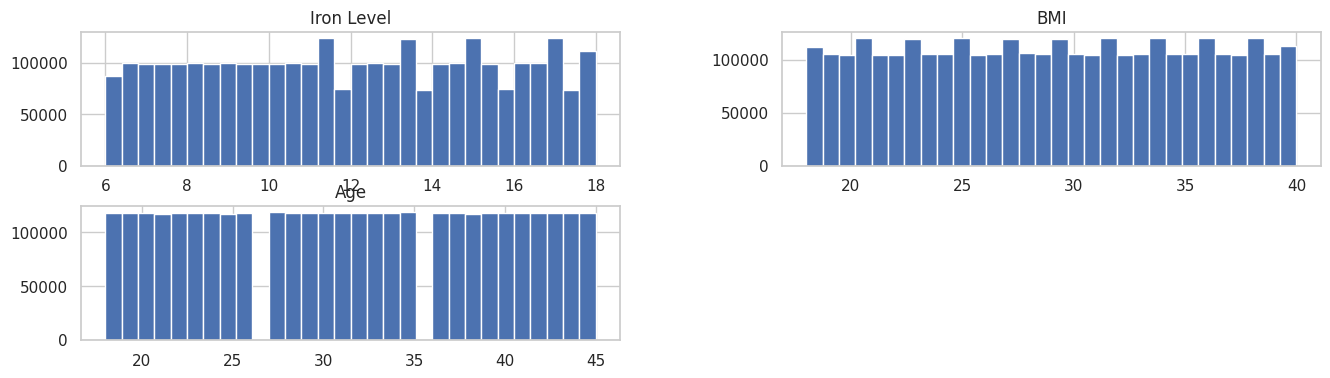

SKEWNESS =
 Iron Level   -0.000149
BMI          -0.001064
Age          -0.000020
dtype: float64


In [16]:
# Limit the data to normal range. e.g remove age near 0 or 100.
# Recheck the data for outlier and skewness.

df = df[df["Age"].between(15, 55)]
df = df[df["BMI"].between(15, 45)]
df[["Iron Level", "BMI", "Age"]].hist(bins=30, figsize=(16,4))
plt.show()

print("SKEWNESS =\n", df[["Iron Level", "BMI", "Age"]].skew())


In [17]:
# Impute the missing values with MEAN
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["BMI"] = df["BMI"].fillna(df["BMI"].mean())
df["Iron Level"] = df["Iron Level"].fillna(df["Iron Level"].mean())



#**Step 5 (optional)**:  Save data on google drive

In [19]:
# This is an optional procedure to save filtered data on google DRIVE and easy loading later. it has three steps

# 1. Mount google drive
from google.colab import drive
drive.mount('/content/drive')

## 2. save data to python paraquet. It is Much faster to read & write. It is smaller on disk (built-in compression). It Keeps data types (int, float, datetime, category, etc.)
#df.to_parquet('/content/drive/MyDrive/processed_Cesarean_data.parquet')

# 3. load data from parquet
df= pd.read_parquet('/content/drive/MyDrive/processed_Cesarean_data.parquet')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  **Step 6**: Data Filtering
In the following step i filtered the data from 4 million to lesser rows for easier plotting.
Initially, I choose only very clean data, with no unknowns, about 270K.
Then, I  choose random 5 thousand cases.
I redefined numeric and categorical columns

In [22]:
#1. Filtering and data selection for further data analysis
#df_filtered = df.iloc[:5000]


df.info() = df[~df.eq("Unknown").any(axis=1)]
df_filtered = df_filtered1.sample(n=5000, random_state= 10 )

for col in df_filtered.select_dtypes(['category']):
    df_filtered[col] = df_filtered[col].cat.remove_unused_categories()


display(df_filtered.head())
display(df_filtered.tail())
print('\n Shape (rows, columns):', df_filtered.shape, '\n')
df_filtered.info()
display(categor_cols)
display(numeric_cols)

#Also, created new columns:
# BMI categories
df_filtered['BMI_categ'] = pd.cut(
    df_filtered['BMI'],
    bins=[-np.inf, 18.5, 24.5, np.inf],
    labels=['Low', 'Normal', 'High'],
    right=False
)

# Iron level categories
df_filtered['Iron_categ'] = pd.cut(
    df_filtered['Iron Level'],
    bins=[-np.inf, 10, 16, np.inf],
    labels=['Anemic', 'Normal', 'Polycythemia'],
    right=False
)

categor_cols = df_filtered.select_dtypes(include=["object","category"]).columns
numeric_cols = df_filtered.select_dtypes(include=['int64', 'float64', 'number']).columns

<class 'pandas.core.frame.DataFrame'>
Index: 3306016 entries, 0 to 3999999
Data columns (total 20 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   IDs                       object  
 1   Age                       float64 
 2   Delivery No               int64   
 3   Delivery Type             category
 4   Blood Pressure            category
 5   Heart Problem             category
 6   Cesarean                  category
 7   BMI                       float64 
 8   Smoking Status            category
 9   Alcohol Use               category
 10  Family History            category
 11  Gestational Diabetes      category
 12  Hospital_Code             category
 13  Mother's Education Level  category
 14  Residence                 category
 15  Income Bracket            category
 16  Folic Acid Supplements    category
 17  Previous Miscarriage      category
 18  Iron Level                float64 
 19  Blood Group               category
dtypes: cate

# **Step 7**. Univariate Analysis
7.1 Numeric variable

    Descriptive statistics
    Histograms and violin plots



7.2 Categorical Features

    Value counts
    Bar plots for top categories

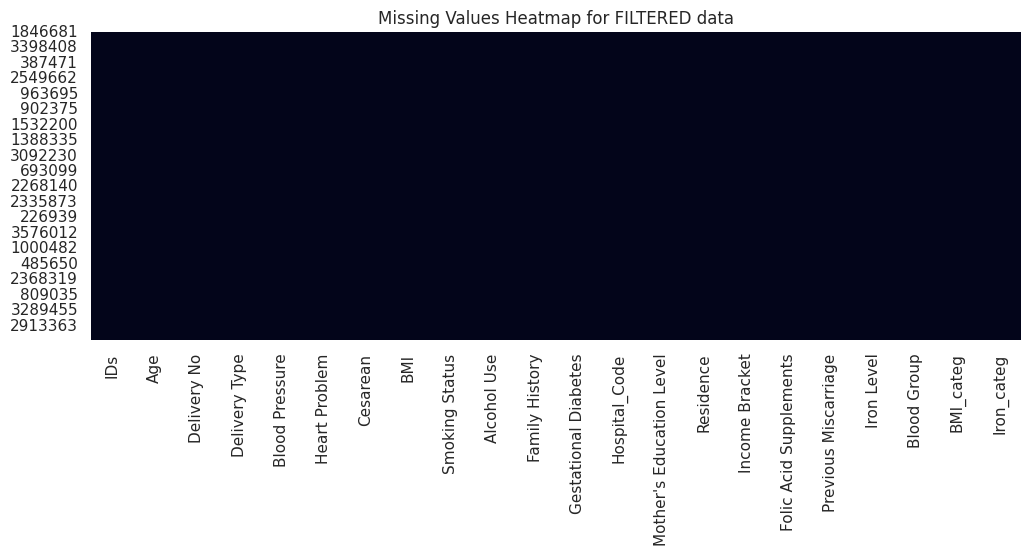

Number of duplicate rows: 0


In [23]:
# 1. QUICK data visualization
# Visual: missingness heatmap
#print('\nMissing values per column (percentage):')
#missing_pct = df_filtered.isnull().mean() * 100
#display(missing_pct.sort_values(ascending=False))

#2.  Visual: missing heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df_filtered.isnull(), cbar=False)
plt.title('Missing Values Heatmap for FILTERED data')
plt.show()
#3.  Identify duplicated rows
num_duplicates = df.duplicated().sum()
print('Number of duplicate rows:', num_duplicates)






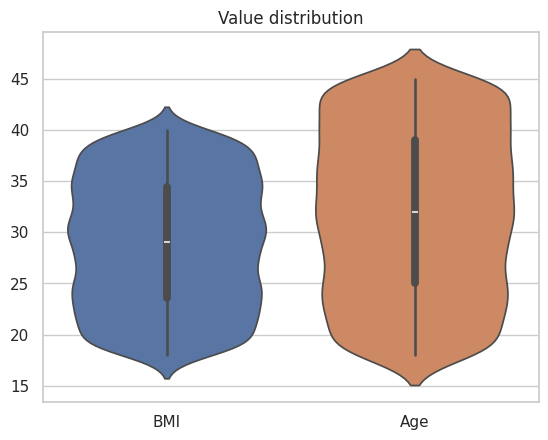

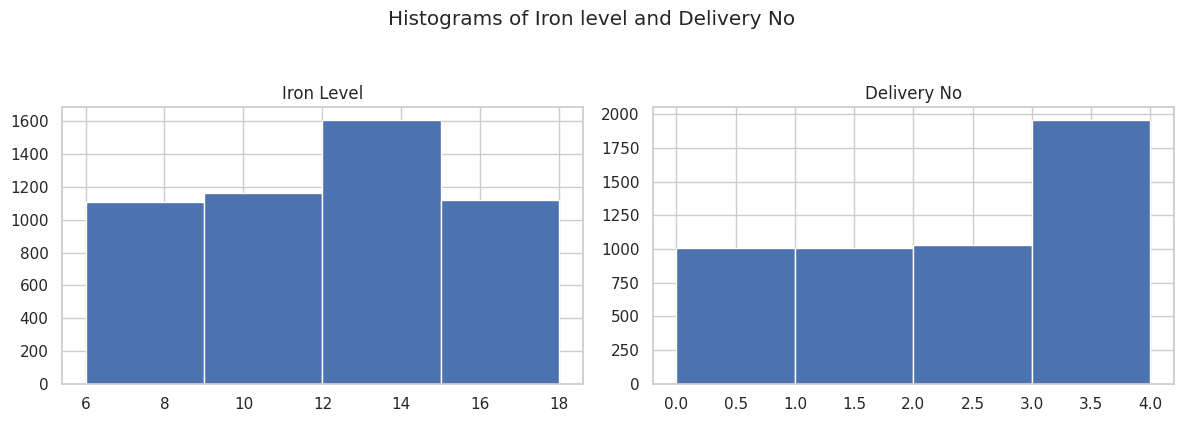

In [24]:
#4.  Visualize distribution of numeric columns using violin and bar plot
sns.violinplot(data=df_filtered[['BMI', 'Age']])
plt.title('Value distribution')
plt.show()

#5.  Histograms
df_filtered[['Iron Level', 'Delivery No']].hist(figsize=(12, 4),bins=4)
plt.suptitle('Histograms of Iron level and Delivery No', y=1.05)
plt.tight_layout()
plt.show()


#  **Step 8**: Selecting target variable

Target column: Cesarean

Target value counts:


,count
Cesarean,
No,2501
Yes,2499



Target value percentages:


,proportion
Cesarean,
No,50.02
Yes,49.98


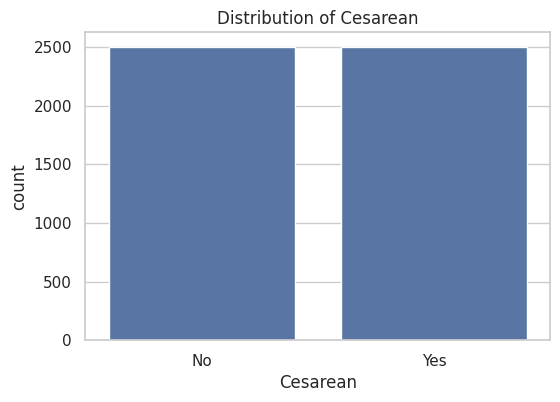

In [26]:
# 1. Selected a target variable
target_col = "Cesarean"

if target_col is not None and target_col in df_filtered.columns:
    print('Target column:', target_col)
    print('\nTarget value counts:')
    display(df_filtered[target_col].value_counts())
    print('\nTarget value percentages:')
    display(df_filtered[target_col].value_counts(normalize=True) * 100)

    plt.figure(figsize=(6,4))
    sns.countplot(x=target_col, data=df_filtered)
    plt.title(f'Distribution of {target_col}')
    plt.show()
else:
    print('No valid target column set. Set target_col to a column name to analyze target.')


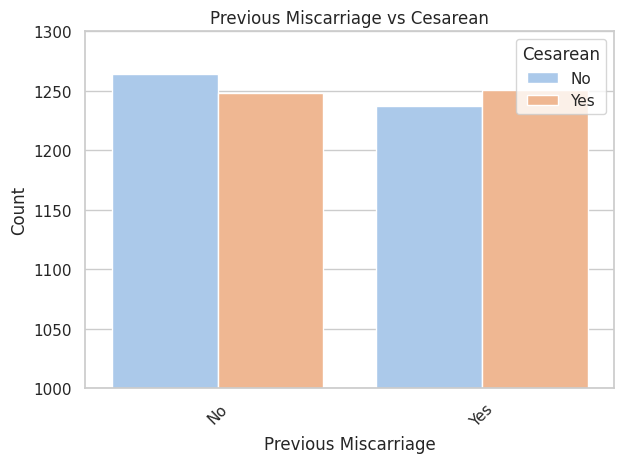

In [27]:
# 2. Comparing TARGET with Previous Miscarriage

sns.countplot(x='Previous Miscarriage', hue=target_col, data=df_filtered, palette='pastel')
plt.title('Previous Miscarriage vs Cesarean')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.ylim(1000,1300)
plt.tight_layout()
plt.show()


# **Step 9**:  Bivariate analysis

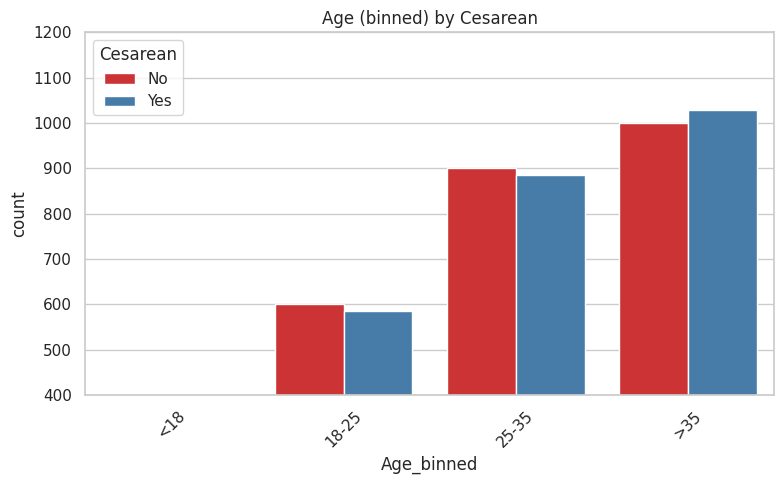

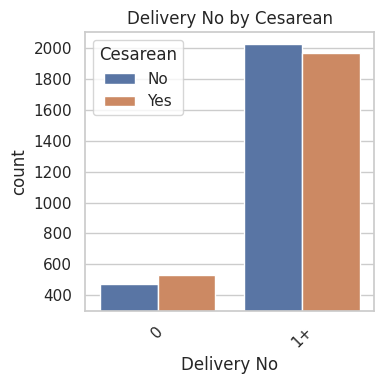

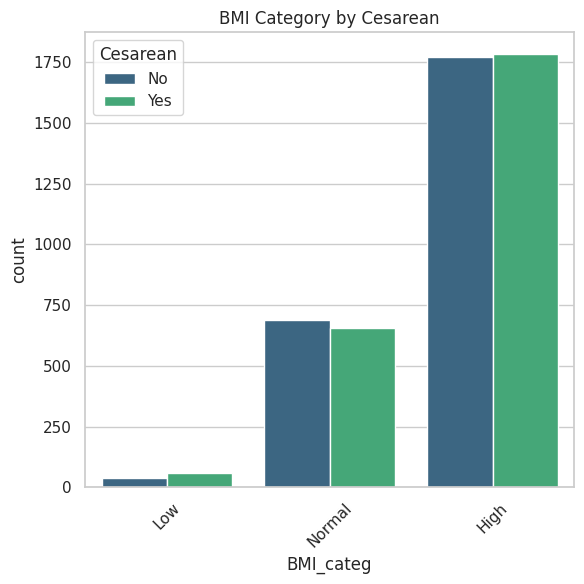

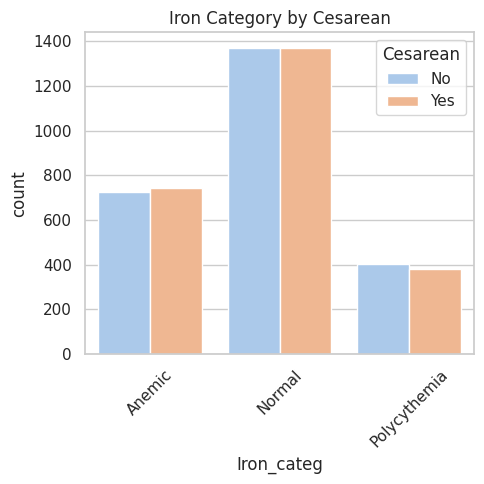

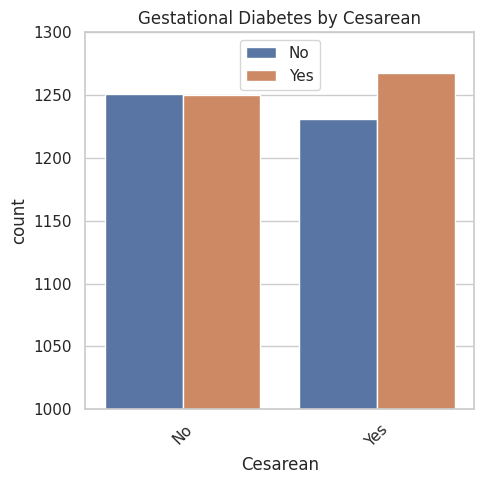

In [28]:

# 1. Age vs target
# Creating Bins for Age
age_bins = [0, 18, 25, 35, np.inf]
age_labels = ['<18', '18-25', '25-35', '>35']
df_filtered['Age_binned'] = pd.cut(df_filtered['Age'], bins=age_bins, labels=age_labels, right=False)


plt.figure(figsize=(8, 5))
sns.countplot(hue=target_col, x='Age_binned', data=df_filtered, palette='Set1')
plt.title(f'Age (binned) by {target_col}')
plt.ylim(400,1200)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Delivery No vs target
plt.figure(figsize=(4, 4))
sns.countplot(x=df_filtered['Delivery No'].apply(lambda x: '0' if x == 0 else '1+'),hue=target_col, data=df_filtered,order=['0', '1+'], palette='deep')
plt.ylim(300,2100)
plt.title(f'Delivery No by {target_col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. BMI category vs target
plt.figure(figsize=(6, 6))
sns.countplot(x='BMI_categ', hue=target_col, data=df_filtered, palette='viridis')
plt.title(f'BMI Category by {target_col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Iron category vs target
plt.figure(figsize=(5, 5))
sns.countplot(x='Iron_categ', hue=target_col, data=df_filtered,palette= 'pastel')
plt.title(f'Iron Category by {target_col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Gestational Diabetes category vs target
plt.figure(figsize=(5,5))
sns.countplot(x=target_col, hue='Gestational Diabetes', data=df_filtered)
plt.title(f'Gestational Diabetes by {target_col}')
plt.xticks(rotation=45)
plt.ylim(1000, 1300)
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

# **Step 10**: Correlation Analysis

  1. Peasrson correlation for Numerical columns
  2. Chi-Square based Cramer's V methods for categorical variables.

  Object 'IDs' was not included for the correlations.   


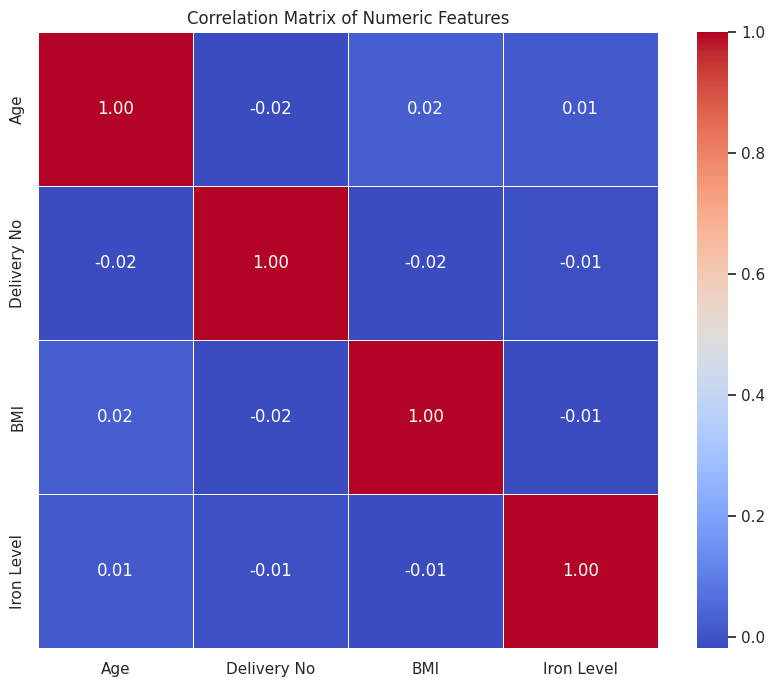

In [29]:
# Correlation plots to check relationship between numeric variable
corr = df_filtered[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


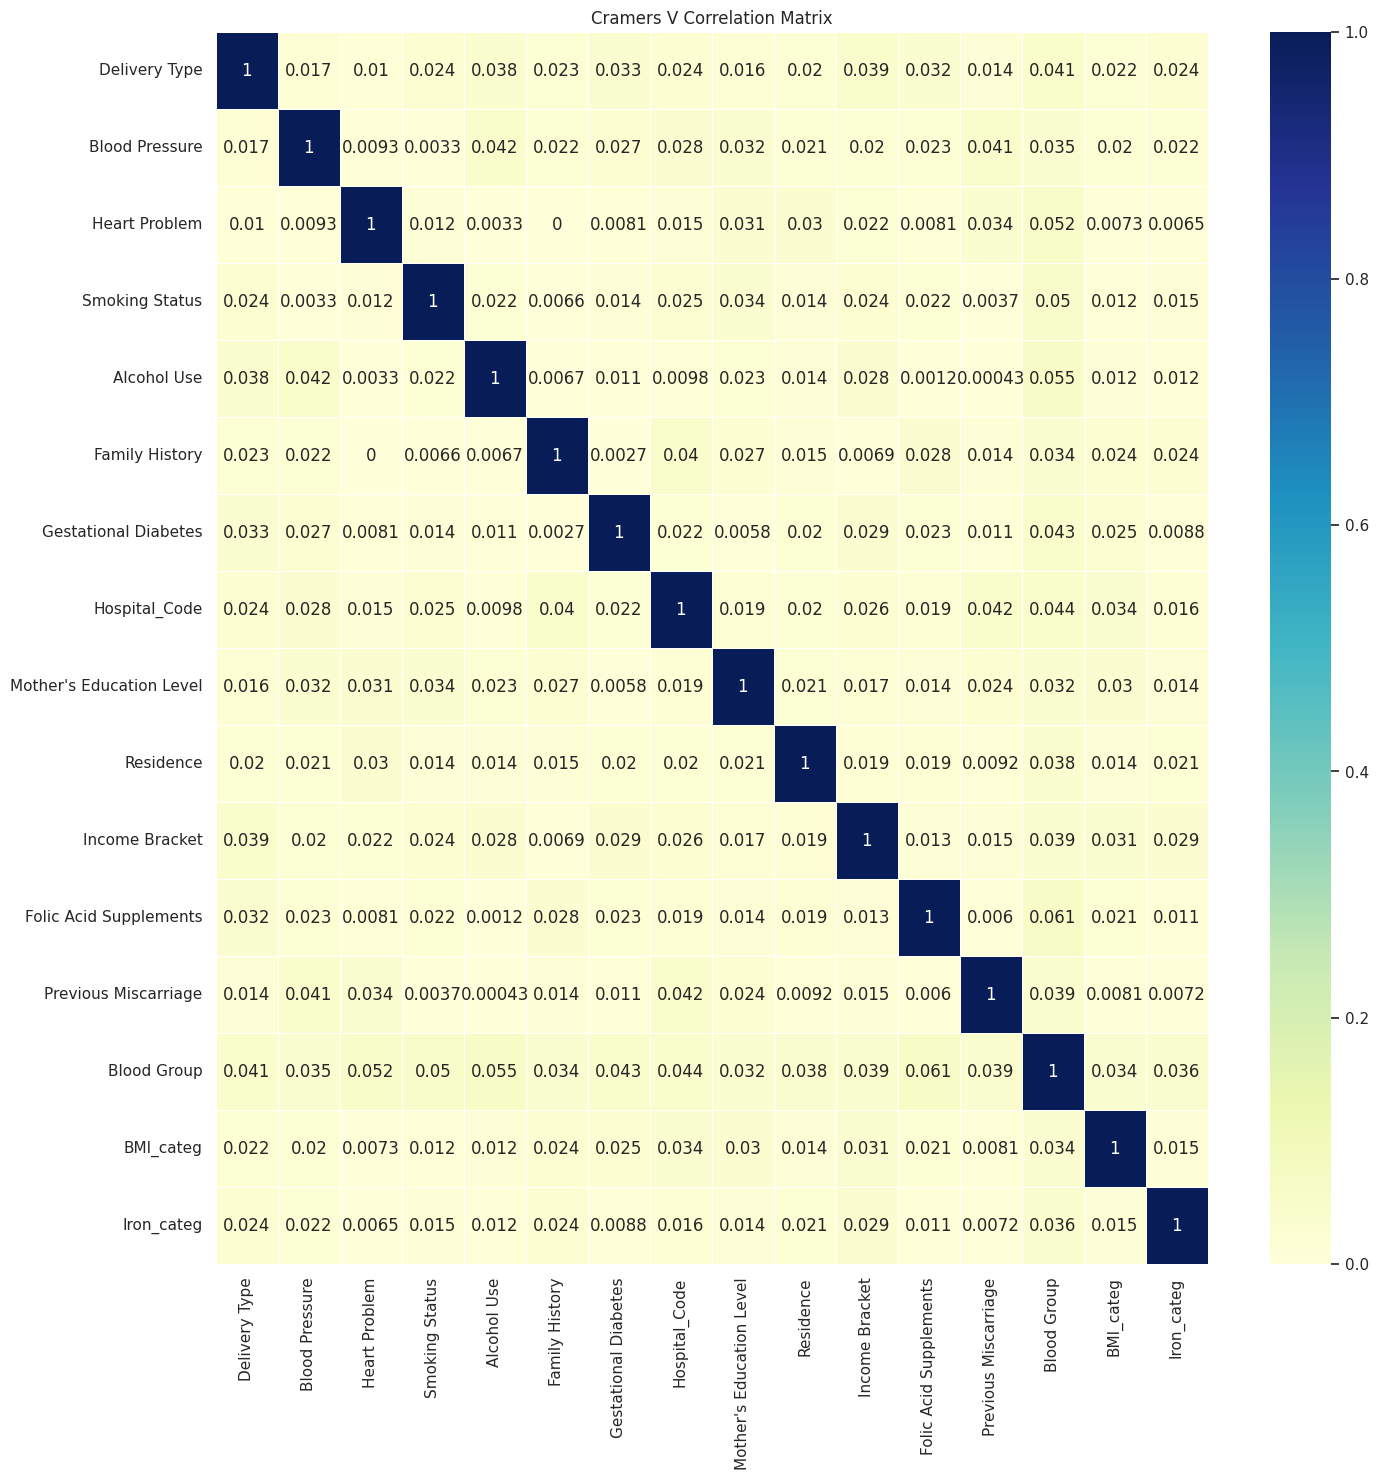

In [37]:
# correlation analysis to get results for categorical data.

##Create function for applying Cramers V test for categorical data
def cramers_v_matrix(df, cols):
    def cramers_v(x, y):
        ct = pd.crosstab(x, y)
        chi2 = chi2_contingency(ct)[0]
        n = ct.sum().sum()
        return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    return pd.DataFrame(
        [[1 if c1 == c2 else cramers_v(df[c1], df[c2]) for c2 in cols]
         for c1 in cols],
        index=cols,
        columns=cols
    )


categ_cols=categor_cols[list(range(1, 4)) + list(range(5, 18))]

cramers_corr = cramers_v_matrix(df_filtered, categ_cols)
plt.figure(figsize=(16, 16))
sns.heatmap(cramers_corr, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Cramers V Correlation Matrix')
plt.show()



# **Step 11**: Grouping varible to answer questions by combining categories

/tmp/ipython-input-1232648133.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_table2 = df_filtered.groupby(['Alcohol Use', 'BMI_categ', 'Cesarean']).size().reset_index(name='Count')


<Figure size 1000x600 with 0 Axes>

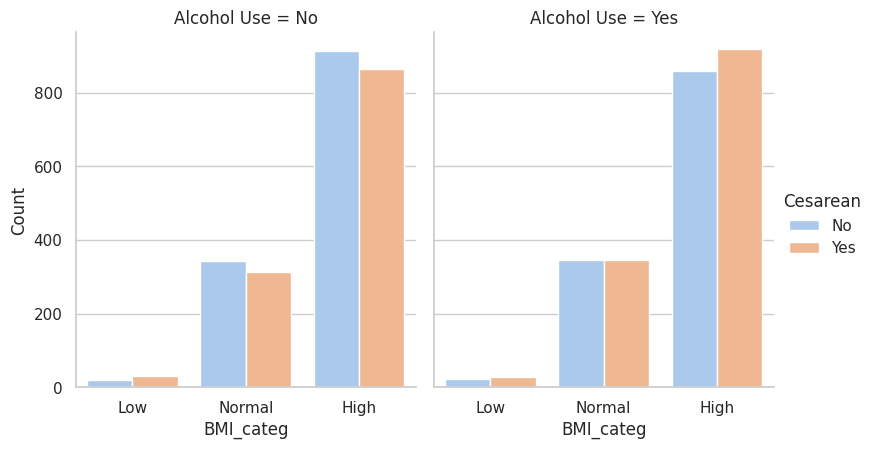

In [38]:
# 1 Does Alcohola and BMI has comibined effect?

combined_table2 = df_filtered.groupby(['Alcohol Use', 'BMI_categ', 'Cesarean']).size().reset_index(name='Count')

# Create a grouped bar plot
plt.figure(figsize=(10,6))
sns.catplot(data=combined_table2,x='BMI_categ',y='Count',hue='Cesarean',col='Alcohol Use',kind='bar',palette='pastel',height=5,aspect=0.8)
plt.subplots_adjust(top=0.85)

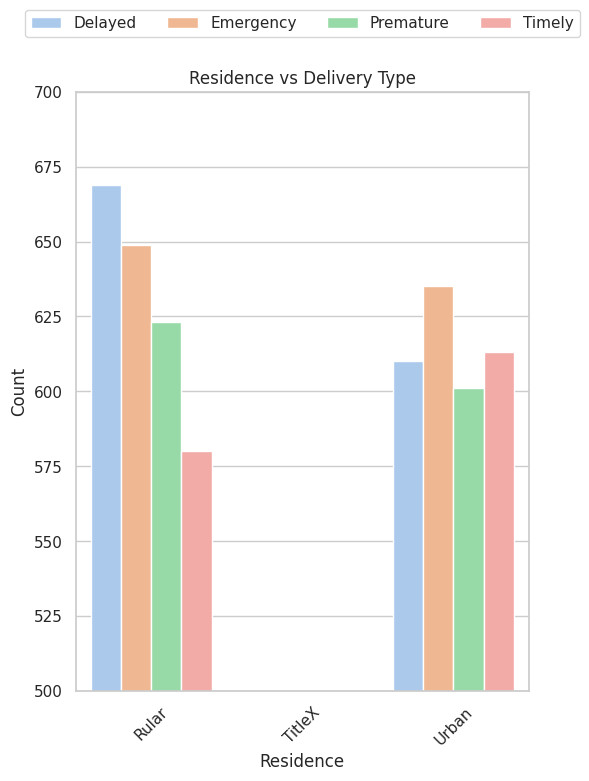

In [62]:
# Does income, and residence affect type of delivery?

cols= 'Residence'
target='Delivery Type'

plt.figure(figsize=(6, 8))
grouped = df_filtered.groupby([cols, target], observed=False).size().reset_index(name='Count')
sns.barplot(data=grouped, x=cols, y='Count', hue=target, palette='pastel')

plt.title(f'{cols} vs {target}')
plt.ylim(500, 700)
plt.xticks(rotation=45)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)

plt.tight_layout()
plt.show()


/tmp/ipython-input-762620885.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bg_counts = df_filtered.groupby(['Blood Group', 'Cesarean']).size().unstack(fill_value=0)


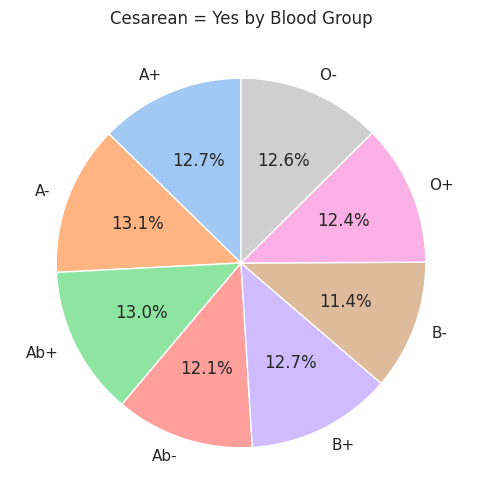

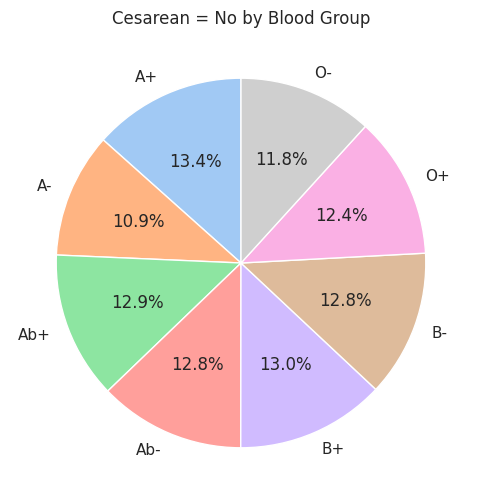

In [49]:
# Group counts by Blood Group and Cesarean
bg_counts = df_filtered.groupby(['Blood Group', 'Cesarean']).size().unstack(fill_value=0)

# Separate series for Yes and No
yes_counts = bg_counts['Yes']
no_counts = bg_counts['No']

# Pie chart for Cesarean = Yes
plt.figure(figsize=(6,6))
plt.pie(yes_counts,labels=yes_counts.index, autopct='%1.1f%%', startangle=90,colors=sns.color_palette('pastel'))
plt.title('Cesarean = Yes by Blood Group')
plt.show()

# Pie chart for Cesarean = No
plt.figure(figsize=(6,6))
plt.pie(no_counts,labels=no_counts.index, autopct='%1.1f%%',startangle=90,colors=sns.color_palette('pastel'))
plt.title('Cesarean = No by Blood Group')
plt.show()

In [ ]:
## Save final data
df_filtered.to_parquet('/content/drive/MyDrive/Filtered_Cesarean_data.parquet')

# **Summary and results**

For the analysis, data was imported from google drive, and initial exploration was done. The original data was obtained from Kaggle with about 4 million rows and 20 columns with different variable. No duplicate records were found. Data cleaning and standardization were carried out, where categorical variables such as delivery type, blood pressure, education level, residence, blood group, and various yes/no questions were standardized for spelling and capitalization, and missing values were treated as “Unknown.” Numerical variables such as age, BMI, and iron level were cleaned by removing outliers in reasonable ranges (e.g., age 15-55, BMI 15-45) and proper imputation. After filtering out doubtful categories, a cleaned dataset of about 5,000 complete records was obtained. For later anlysis, two new categorical variables, BMI_categ and Iron_categ, were created. Univariate analysis was performed using histograms and violin plots to display the distribution of important numerical variables like age, BMI, iron level, and delivery number. This was followed by bivariate exploration and grouping, where the distribution of cesarean section deliveries versus traditional deliveries was explored with respect to various maternal characteristics and conditions such as age, previous miscarriages, gestational diabetes, smoking and alcohol use, family history, blood pressure, and heart problems.

This is achieved through various comparisons, such as comparing the proportions of the population based on certain categorical variables, such as whether the mother had a previous miscarriage, the age group of the mother, and gestational diabetes, among others. In order to visualize the results of the analysis, various pie charts and bar plots were created, which provided a clear and concise summary of the results of the analysis, highlighting the various contributions of the various groups in the population to the Cesarean and traditional deliveries. Moreover, the analysis also sought to understand the potential relationships that exist between various aspects of the mother, such as BMI, alcohol, and residence type, and the type of delivery, as well as the various correlations that exist in the dataset, which could highlight any strong relationships that might exist in the dataset.

Some weak to moderate associations were found between various maternal and clinical variables and Cesarean section. Specifically, gestational diabetes, first-time pregnancy, previous miscarriages, young maternal age, and alcohol use were some of the more apparent variables that were associated with Cesarean sections. On the other hand, the effects of iron level, blood group, and BMI differences were subtle or minimal when each was considered separately. In general, there were no strong correlations found across the set of variables, which suggests a complex relationship between variables rather than a direct relationship.
A copy of the processed data and filtered data has been saved to google drive
